# Evaluate BED

Evaluate aline on BED tasks

In [1]:
import torch

import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl


import random
import os
import sys
from hydra import initialize, compose
from hydra.utils import instantiate
from omegaconf import OmegaConf

# Add the project root to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)


from utils import set_seed, load_state_dict
from utils.eval import eval_boed

from utils import create_target_mask, select_targets_by_mask, compute_ll

from model import Aline

COLORS = ['#0072B2', '#009E73', '#D55E00', '#CC79A7', '#F0E442', '#56B4E9']
plt.style.use(['seaborn-v0_8-colorblind'])

In [2]:
def load(config_overrides=[], state_dict=None, config_name="train_bed", verbose=False):
    # Initialise the hyper params
    with initialize(version_base=None, config_path="../config"):
        cfg = compose(config_name=config_name, overrides=config_overrides)
        
    if verbose:
        print(OmegaConf.to_yaml(cfg))


    # Setting device
    if not torch.cuda.is_available():
        cfg.device = "cpu"
    torch.set_default_device(cfg.device)
    if cfg.device == "cuda":
        torch.set_default_dtype(torch.float32)
        torch.set_default_device("cuda")

    # Setting random seed
    if cfg.fix_seed:
        set_seed(cfg.seed)
    else:
        cfg.seed = torch.random.seed()

    # Data
    experiment = instantiate(cfg.task)

    # Model
    embedder = instantiate(cfg.embedder)
    encoder = instantiate(cfg.encoder)
    head = instantiate(cfg.head)
    model = Aline(embedder, encoder, head)
    

    if state_dict is not None:
        model = load_state_dict(model, "." + cfg.output_dir, state_dict)


    return cfg, experiment, model

## Location Finding

### EIG Bounds

In [13]:
n_query = 2000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "aae_Location_d2_1.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 10, cfg.time_token)

Step 0: PCE 14.439508438110352, NMC 16.732168197631836
Step 1: PCE 14.805929183959961, NMC 16.887041091918945
Step 2: PCE 14.64653205871582, NMC 16.762893676757812
Step 3: PCE 14.810953140258789, NMC 16.855365753173828
Step 4: PCE 14.808235168457031, NMC 17.10708999633789
Step 5: PCE 15.007944107055664, NMC 16.90110206604004
Step 6: PCE 14.64982795715332, NMC 16.79566764831543
Step 7: PCE 14.942422866821289, NMC 16.80934715270996
Step 8: PCE 13.65045166015625, NMC 14.908523559570312
Step 9: PCE 14.27125072479248, NMC 15.532896041870117
Step 10: PCE 15.041142463684082, NMC 17.641199111938477
Step 11: PCE 14.9124116897583, NMC 16.697986602783203
Step 12: PCE 14.5341796875, NMC 17.101991653442383
Step 13: PCE 14.520919799804688, NMC 15.924975395202637
Step 14: PCE 15.208219528198242, NMC 17.364349365234375
Step 15: PCE 15.28503131866455, NMC 19.145009994506836
Step 16: PCE 15.209118843078613, NMC 17.94788932800293
Step 17: PCE 14.243695259094238, NMC 16.627635955810547
Step 18: PCE 14.473

In [17]:
bounds

AttrDict({'pce_mean': tensor(14.7349), 'pce_err': tensor(0.0473), 'nmc_mean': tensor(16.9711), 'nmc_err': tensor(0.1303)})

In [20]:
@torch.no_grad()
def plot_policy2d(model, experiment, T=30, N=200, title="", posterior=True):
    # Get trace
    model.eval()
    design_indices = []         # action: indices of the chosen designs
    action_log_probs = []       # log probs of design history
    full_action_probs = []  # log probs of all designs
    nlls_for_prediction = []
    nlls_for_query = []

    experiment.n_query_init = N

    batch = experiment.sample_batch(1)

    # T-steps experiment

    mask_type = random.choice(cfg.task.mask_type)
    batch.target_mask = create_target_mask(mask_type,
                                        cfg.task.embedding_type,
                                        cfg.task.n_target_data,
                                        cfg.task.n_target_theta,
                                        cfg.task.n_selected_targets,
                                        cfg.task.predefined_masks,
                                        cfg.task.predefined_mask_weights,
                                        cfg.task.mask_index,
                                        cfg.task.attend_to)

    for t in range(T):
        pred = model.forward(batch)

        idx = pred.design_out.idx                           # [B, 1]
        design_indices.append(idx)

        # Update the batch
        batch = experiment.update_batch(batch, idx)

        # Action log probs
        action_log_probs.append(pred.design_out.log_prob)   # [B]
        full_action_probs.append(pred.design_out.zt)    # [B, N_design]

        # NLLs
        target_ll = compute_ll(batch.target_all,
                                pred.posterior_out.mixture_means,
                                pred.posterior_out.mixture_stds,
                                pred.posterior_out.mixture_weights)  # [B, n_target]

        masked_target_ll = select_targets_by_mask(target_ll, batch.target_mask)

        if cfg.task.embedding_type == "mix" and mask_type == "all":
            nll_for_query = - (masked_target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1) +
                                masked_target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1))
        else:
            nll_for_query = - masked_target_ll.mean(dim=-1)
        nlls_for_query.append(nll_for_query)

        if cfg.task.embedding_type == "mix":
            nll = - (target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1) +
                        target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1))
        else:
            nll = - target_ll.mean(dim=-1)
        nlls_for_prediction.append(nll)

    log_probs = torch.stack(action_log_probs, dim=1)


    norm = plt.Normalize(0, 1)  # Normalize colors between 0 and 1
    log_probs_exp = log_probs[0].exp().cpu().numpy()  # Convert log probs to probabilities
    alpha_values = log_probs_exp # / log_probs_exp.max()  # Normalize alpha between 0 and 1
    color_values = np.arange(1, T+1, 1) / T  # Normalize time steps to [0,1]

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4))

    # Plot the posterior
    if posterior:
        # For contour plot
        num_point = 200
        x = torch.linspace(0, 1, num_point)
        y = torch.linspace(0, 1, num_point)
        X, Y = torch.meshgrid(x, y)
        pos = torch.stack([X, Y], dim=-1).reshape(1, -1, 2, 1)

        prob = compute_ll(pos, 
                          pred.posterior_out.mixture_means,
                                pred.posterior_out.mixture_stds,
                                pred.posterior_out.mixture_weights).sum(-1)[0]
        
        contourf = ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), prob.reshape(num_point, num_point).cpu().numpy(), 16, cmap=mpl.cm.bone) # PuBu_r

        # add color bar
        cbar_pos = fig.colorbar(contourf, ax=ax)
        cbar_pos.set_label(r'Posterior $\log q(\theta \, | \,  \mathcal{D}_T)$', 
                           rotation=270, verticalalignment='baseline')

    # scatter plot
    scatter = ax.scatter(
        batch.context_x[0, :T, 0].cpu().numpy(), 
        batch.context_x[0, :T, 1].cpu().numpy(), 
        c=color_values, cmap='summer', norm=norm, label=r'$\xi_t$'
    )



    # Add first colorbar for time step (color)
    cbar1 = fig.colorbar(scatter, ax=ax)
    cbar1.set_label(r'Time step $t/T$', rotation=270, verticalalignment='baseline', fontsize=12)


    # Plot theta points
    theta = batch.target_theta.reshape(-1, experiment.K, experiment.dim_x)
    ax.scatter(theta[0, :, 0].cpu().numpy(), theta[0, :, 1].cpu().numpy(), color=COLORS[3], label=r'$\theta$', marker='*', s=120)



    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if not os.path.exists('../outputs/figures'):
        os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/bed_loc.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [24]:
@torch.no_grad()
def plot_policy2d_two_sources(
    model,
    experiment,
    cfg,
    T=30,
    N=200,
    title="",
    posterior=True,
    save_path="../outputs/figures/bed_loc.pdf",
):
    """
    Plot a 2D policy rollout for a localization task with K=2 sources in dim_x=2.

    Assumptions:
    - experiment.K == 2
    - experiment.dim_x == 2
    - theta is either stored in batch.target_theta or batch.target_all
    - theta shape can be [B, K, 2] or [B, K*2]
    - designs xi are 2D points, stored in batch.context_x
    """

    import os
    import random
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    model.eval()

    design_indices = []
    action_log_probs = []
    full_action_probs = []
    nlls_for_prediction = []
    nlls_for_query = []

    experiment.n_query_init = N

    batch = experiment.sample_batch(1)

    device = batch.context_x.device

    # Build target mask
    mask_type = random.choice(cfg.task.mask_type)

    batch.target_mask = create_target_mask(
        mask_type,
        cfg.task.embedding_type,
        cfg.task.n_target_data,
        cfg.task.n_target_theta,
        cfg.task.n_selected_targets,
        cfg.task.predefined_masks,
        cfg.task.predefined_mask_weights,
        cfg.task.mask_index,
        cfg.task.attend_to,
    )

    pred = None

    for t in range(T):
        pred = model.forward(batch)

        idx = pred.design_out.idx  # [B, 1] or [B]
        design_indices.append(idx)

        batch = experiment.update_batch(batch, idx)

        action_log_probs.append(pred.design_out.log_prob)  # [B]
        full_action_probs.append(pred.design_out.zt)       # [B, N_design]

        target_ll = compute_ll(
            batch.target_all,
            pred.posterior_out.mixture_means,
            pred.posterior_out.mixture_stds,
            pred.posterior_out.mixture_weights,
        )

        masked_target_ll = select_targets_by_mask(target_ll, batch.target_mask)

        if cfg.task.embedding_type == "mix" and mask_type == "all":
            nll_for_query = -(
                masked_target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1)
                + masked_target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1)
            )
        else:
            nll_for_query = -masked_target_ll.mean(dim=-1)

        nlls_for_query.append(nll_for_query)

        if cfg.task.embedding_type == "mix":
            nll = -(
                target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1)
                + target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1)
            )
        else:
            nll = -target_ll.mean(dim=-1)

        nlls_for_prediction.append(nll)

    log_probs = torch.stack(action_log_probs, dim=1)

    # ---------------------------------------------------------------------
    # Recover theta as [B, K, dim_x]
    # ---------------------------------------------------------------------
    if hasattr(batch, "target_theta"):
        theta_raw = batch.target_theta
    elif hasattr(batch, "theta"):
        theta_raw = batch.theta
    else:
        theta_raw = batch.target_all

    K = getattr(experiment, "K", 2)
    dim_x = getattr(experiment, "dim_x", 2)

    theta = theta_raw.reshape(theta_raw.shape[0], K, dim_x)

    assert K == 2, f"Expected K=2 sources, got K={K}"
    assert dim_x == 2, f"Expected dim_x=2, got dim_x={dim_x}"

    # ---------------------------------------------------------------------
    # Figure
    # ---------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))

    norm = plt.Normalize(0, 1)
    color_values = np.arange(1, T + 1) / T

    # ---------------------------------------------------------------------
    # Posterior visualization
    # ---------------------------------------------------------------------
    if posterior:
        num_point = 200

        x = torch.linspace(0, 1, num_point, device=device)
        y = torch.linspace(0, 1, num_point, device=device)

        X, Y = torch.meshgrid(x, y, indexing="ij")
        grid_2d = torch.stack([X, Y], dim=-1).reshape(-1, 2)  # [G, 2]

        # We cannot directly plot the full posterior over R^4.
        # Instead, we plot a 2D slice/marginal-like view:
        # source 1 varies on the grid while source 2 is fixed to its true value,
        # and source 2 varies on the grid while source 1 is fixed to its true value.
        theta_true = theta[0]  # [2, 2]

        pos_source_1 = torch.empty(grid_2d.shape[0], K, dim_x, device=device)
        pos_source_1[:, 0, :] = grid_2d
        pos_source_1[:, 1, :] = theta_true[1].unsqueeze(0).expand_as(grid_2d)

        pos_source_2 = torch.empty(grid_2d.shape[0], K, dim_x, device=device)
        pos_source_2[:, 0, :] = theta_true[0].unsqueeze(0).expand_as(grid_2d)
        pos_source_2[:, 1, :] = grid_2d

        # Flatten grid as an artificial batch: [G, K * dim_x]
        pos_source_1_flat = pos_source_1.reshape(-1, K * dim_x)
        pos_source_2_flat = pos_source_2.reshape(-1, K * dim_x)

        G = pos_source_1_flat.shape[0]

        means = pred.posterior_out.mixture_means
        stds = pred.posterior_out.mixture_stds
        weights = pred.posterior_out.mixture_weights

        # The posterior was computed for B=1. We expand it to all grid points.
        # Typical shapes:
        # means:   [1, n_target, n_components] -> [G, n_target, n_components]
        # stds:    [1, n_target, n_components] -> [G, n_target, n_components]
        # weights: [1, n_target, n_components] or [1, n_components]
        means_grid = means.expand(G, *means.shape[1:])
        stds_grid = stds.expand(G, *stds.shape[1:])
        weights_grid = weights.expand(G, *weights.shape[1:])

        prob_1 = compute_ll(
            pos_source_1_flat,
            means_grid,
            stds_grid,
            weights_grid,
        ).sum(dim=-1)

        prob_2 = compute_ll(
            pos_source_2_flat,
            means_grid,
            stds_grid,
            weights_grid,
        ).sum(dim=-1)

        # Combine both source-wise posterior slices.
        # This gives a readable 2D score map showing regions compatible with either source.
        prob = torch.logsumexp(torch.stack([prob_1, prob_2], dim=0), dim=0)

        contourf = ax.contourf(
            X.cpu().numpy(),
            Y.cpu().numpy(),
            prob.reshape(num_point, num_point).cpu().numpy(),
            16,
            cmap=mpl.cm.bone,
        )

        cbar_pos = fig.colorbar(contourf, ax=ax)
        cbar_pos.set_label(
            r'Posterior slice $\log q(\theta \mid \mathcal{D}_T)$',
            rotation=270,
            verticalalignment='baseline',
            fontsize=12,
        )

    # ---------------------------------------------------------------------
    # Plot selected designs
    # ---------------------------------------------------------------------
    context_x = batch.context_x[0]

    # Depending on the ALINE wrapper, context_x may include the initial dummy context.
    # If so, skip the first point and keep the T actual queried designs.
    if context_x.shape[0] >= T + 1:
        designs = context_x[1:T + 1]
    else:
        designs = context_x[:T]

    scatter = ax.scatter(
        designs[:, 0].cpu().numpy(),
        designs[:, 1].cpu().numpy(),
        c=color_values[: designs.shape[0]],
        cmap="summer",
        norm=norm,
        label=r"$\xi_t$",
        s=40,
    )

    cbar1 = fig.colorbar(scatter, ax=ax)
    cbar1.set_label(
        r"Time step $t/T$",
        rotation=270,
        verticalalignment="baseline",
        fontsize=12,
    )

    # ---------------------------------------------------------------------
    # Plot true source locations
    # ---------------------------------------------------------------------
    theta_np = theta[0].cpu().numpy()

    ax.scatter(
        theta_np[0, 0],
        theta_np[0, 1],
        label=r"$\theta_1$",
        marker="*",
        s=160,
    )

    ax.scatter(
        theta_np[1, 0],
        theta_np[1, 1],
        label=r"$\theta_2$",
        marker="*",
        s=160,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(title)

    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

    return {
        "batch": batch,
        "pred": pred,
        "theta": theta,
        "design_indices": design_indices,
        "log_probs": log_probs,
        "nlls_for_prediction": torch.stack(nlls_for_prediction, dim=1),
        "nlls_for_query": torch.stack(nlls_for_query, dim=1),
    }

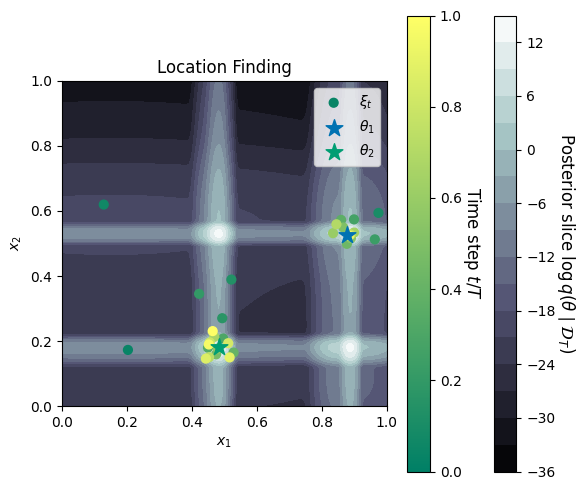

In [28]:
out = plot_policy2d_two_sources(model, experiment, cfg, 30, title="Location Finding", N=2000)

## CES

### EIG Bounds

In [ ]:
cfg, experiment, model = load(["task=ces", f"task.n_query_init={n_query}"], "aline_ces.pth")

bounds = eval_boed(model, experiment, cfg.T-1, int(1e7), 2000, 10, cfg.time_token)

In [ ]:
@torch.no_grad()
def plot_posterior(model, experiment, T=30, N=200, title="CES"):
    # Evaluate model and generate data
    model.eval()
    experiment.n_query_init = N
    batch = experiment.sample_batch(1)
    theta = batch.target_theta.squeeze(-1)

    # Run T steps
    for t in range(T):
        pred = model.forward(batch)
        idx = pred.design_out.idx
        batch = experiment.update_batch(batch, idx)

    # Extract target variables
    rho = theta[..., 0]
    alpha = theta[..., 1:4]
    log_u = theta[..., 4]

    # Setup subplots
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    line_width = 2
    alpha_grid = 0.5

    # --- Plot rho ---
    ax = axes[0]
    x = torch.linspace(0, 1, 100).unsqueeze(-1)
    prob = compute_ll(x,
                      pred.posterior_out.mixture_means[:, 0],
                      pred.posterior_out.mixture_stds[:, 0],
                      pred.posterior_out.mixture_weights[:, 0]).exp()
    ax.plot(x.cpu().numpy(), prob.cpu().numpy(), linewidth=line_width)
    ax.axvline(rho.cpu().numpy(), color='#f55f51', linestyle='--')
    ax.set_title(r"$\rho$")
    ax.set_xlabel(r"$\rho$")
    # ax.set_ylabel(r"$p(\rho)$")
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    # Add minor ticks
    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    # ax.grid(True, linestyle='--', alpha=alpha_grid)

    # --- Plot alpha ---
    ax = axes[1]
    x = torch.linspace(0, 1, 100).unsqueeze(-1)
    for i, a in enumerate(alpha.squeeze(0)):
        prob = compute_ll(x,
                          pred.posterior_out.mixture_means[:, i + 1],
                          pred.posterior_out.mixture_stds[:, i + 1],
                          pred.posterior_out.mixture_weights[:, i + 1]).exp()
        ax.plot(x.cpu().numpy(), prob.cpu().numpy(), linewidth=line_width)
        ax.axvline(a.cpu().numpy(), color='#f55f51', linestyle='--')
    ax.set_title(r"$\alpha$")
    ax.set_xlabel(r"$\alpha$")
    # ax.set_ylabel(r"$p(\alpha)$")
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    # Add minor ticks
    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    # ax.grid(True, linestyle='--', alpha=alpha_grid)

    # --- Plot log(u) ---
    ax = axes[2]
    x = torch.linspace(-6, 8, 100).unsqueeze(-1)
    prob = compute_ll(x,
                      pred.posterior_out.mixture_means[:, 4],
                      pred.posterior_out.mixture_stds[:, 4],
                      pred.posterior_out.mixture_weights[:, 4]).exp()
    ax.plot(x.cpu().numpy(), prob.cpu().numpy(), linewidth=line_width)
    ax.axvline(log_u.cpu().numpy(), color='#f55f51', linestyle='--')
    ax.set_title(r"$u$")
    ax.set_xlabel(r"$\log(u)$")
    # ax.set_ylabel(r"$p(\log(u))$")
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    # Add minor ticks
    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    # ax.grid(True, linestyle='--', alpha=alpha_grid)

    # Add ONE y-label for the whole figure
    fig.text(0.05, 0.5, r"$p(\theta)$", va='center', rotation='vertical', fontsize=14)

    # Final layout tweaks
    fig.suptitle(title, fontweight='bold')
    fig.tight_layout(rect=[0.05, 0, 1, 1])
    if not os.path.exists('../outputs/figures'):
        os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/bed_pos_ces.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
plot_posterior(model, experiment, T=10, N=n_query, title=None)

### **Simple Pendulum**